In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import pandas as pd
from utils.preprocess import *
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
from eval.eval import *
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
############################################################

In [3]:
config = load_config(overrides=['dataset=mouse'])
OmegaConf.set_struct(config, False)

config.classifier.num_layers = 2
config.classifier.hidden_dim = 128
config.classifier.epsilon = 0.05

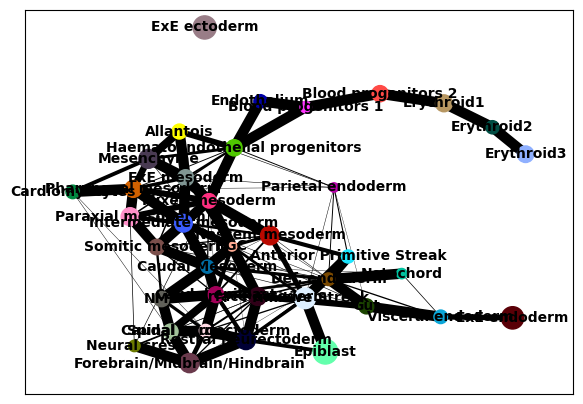

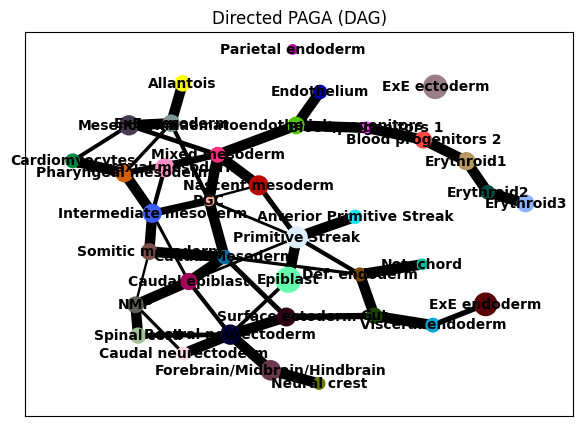

In [ ]:
# path = "data"
# cache_file = os.path.join(path, "atlas", "mouse_preprocessed.h5ad")
# adata = sc.read(cache_file)

# adata.obs['cell_type'] = adata.obs['celltype'].astype(str)

# stage_to_num = {
# 'E6.5': 6.5, 'E6.75': 6.75, 'E7.0': 7.0, 'E7.25': 7.25,
# 'E7.5': 7.5, 'E7.75': 7.75, 'E8.0': 8.0, 'E8.25': 8.25, 'E8.5': 8.5
# }
# adata.obs['timepoint'] = adata.obs['stage'].map(stage_to_num).astype(float)

# # PCA
# sc.tl.pca(adata, n_comps=config.pc_dim, mask_var=None)
# adata.uns['std'] = np.ones((1, config.pc_dim))

# sc.pp.neighbors(adata, use_rep="X_pca")
# sc.tl.paga(adata, groups='cell_type')
# sc.pl.paga(adata, threshold=0.03, show=False)

# directed_conn, _ = enforce_dag_from_root(
# adata, 
# root_cell_type="Epiblast",
# groups='cell_type',
# threshold=0.2
# )

# original_conn = adata.uns['paga']['connectivities'].copy()
# adata.uns['paga']['connectivities'] = adata.uns['paga']['connectivities_dag']

# sc.pl.paga(adata, threshold=0.2, title='Directed PAGA (DAG)')
# adata.uns['paga']['connectivities'] = original_conn

In [7]:
### SETTINGS ###

adata = process_data(pc_dim=config.pc_dim, 
                     t0_index=config.t0_index,
                     t1_index=config.t1_index,
                     data=config.dataset, 
                     use_paga=config.use_paga,
                     tissue=config.tissue)

print(adata.obs['cell_type'].nunique())

timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

config.num_classes = adata.obs['cell_type'].nunique()

print(config.t0_index)
print(config.t1_index)

Loading cached preprocessed mouse data...
35
3
8


/home/azweig/projects/finfm/utils/lineage.py:255: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['stoi'] = stoi


In [ ]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

adata = adata[(adata.obs['timepoint'] >= t0) & (adata.obs['timepoint'] <= t1)]
adata_train = adata[adata.obs['timepoint'].isin([t0, t1])]

print(t0, t1)

In [ ]:
# # Explore cell types and stages
# print("Cell types:")
# for ct in sorted(adata.obs['cell_type'].unique()):
#     n = (adata.obs['cell_type'] == ct).sum()
#     print(f"  {ct}: {n}")

# print(f"\nStages:")
# for t in timepoints:
#     n = (adata.obs['timepoint'] == t).sum()
#     print(f"  {t}: {n}")

In [ ]:
# # Visualize tree structure
# itos = adata.uns['itos']
# N = adata.uns['tree'].shape[0]
# print("Tree edges:")
# for i in range(N):
#     for j in range(N):
#         if adata.uns['tree'][i][j] == 1.0:
#             print(f"  {itos[i]} -> {itos[j]}")

Tree edges:
  Caudal neurectoderm -> NMP
  Pharyngeal mesoderm -> Cardiomyocytes
  Intermediate mesoderm -> Pharyngeal mesoderm
  Intermediate mesoderm -> Paraxial mesoderm
  Intermediate mesoderm -> Somitic mesoderm
  NMP -> Somitic mesoderm
  Primitive Streak -> Anterior Primitive Streak
  Primitive Streak -> Caudal epiblast
  Primitive Streak -> PGC
  Primitive Streak -> Def. endoderm
  Primitive Streak -> Nascent mesoderm
  Caudal Mesoderm -> Somitic mesoderm
  Blood progenitors 2 -> Erythroid1
  Caudal epiblast -> Intermediate mesoderm
  Caudal epiblast -> NMP
  Caudal epiblast -> Caudal Mesoderm
  Mixed mesoderm -> Pharyngeal mesoderm
  Mixed mesoderm -> Haematoendothelial progenitors
  Mixed mesoderm -> Paraxial mesoderm
  Mixed mesoderm -> Mesenchyme
  Haematoendothelial progenitors -> Endothelium
  Haematoendothelial progenitors -> Blood progenitors 1
  PGC -> Intermediate mesoderm
  PGC -> Caudal Mesoderm
  PGC -> Mixed mesoderm
  PGC -> ExE mesoderm
  Erythroid1 -> Erythroid

In [ ]:
# #CFM
# config.metric = "cfm"
# config.no_learning = True
# config.metric_max_epochs = 2

In [ ]:
#CFM + Finsler
config.metric = "cfm"

config.finsler.use = True
config.finsler.lamb = 0.5
config.balance_classes = False
config.metric_max_epochs = 2

In [ ]:
# #MFM-Euc
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = True

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

In [ ]:
# #MFM
# config.metric = "mfm"

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

In [ ]:
# #MFM + Finsler
# config.metric = "mfm"

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

# # config.finsler.use = True
# # config.finsler.lamb = 0.5

In [ ]:
adata

In [ ]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [ ]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=config.project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

In [ ]:
remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [ ]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

w1_scores = []
for index in range(config.t0_index + 1, config.t1_index):
    print(index)
    t = timepoints[index]
    w1 = predict(embed_model, adata, t0, t, t1, num_traj=6000, library="pot")
    w1_scores.append(w1)
w1_scores = torch.tensor(w1_scores)
print(w1_scores)
print(torch.mean(w1_scores))

In [ ]:
device = embed_model.device

batch = next(iter(paired_dataloader))
x0, x1, _, _ = embed_model._prepare_batch(batch)

paths = embed_model.sample_geodesic_path(batch, num_points=50)
paths_flat = paths.reshape(-1, paths.shape[-1])

time_axis = np.linspace(0, 1, 50)

with torch.no_grad():
    logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    
probs = probs.reshape(paths.shape[0], paths.shape[1], -1)

itos = adata.uns['itos']
cell_types = [itos[i] for i in range(len(itos))] + ["outlier"]

fig, axes = plt.subplots(5, figsize=(12, 8), sharex=True, sharey=True)

flat_axes = axes.flatten()

for i in range(len(flat_axes)):
    traj = probs[:,i]
    ax = flat_axes[i]
    ax.stackplot(time_axis, traj.T, labels=cell_types, alpha=0.8, colors=plt.cm.tab20.colors)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

handles, labels = flat_axes[0].get_legend_handles_labels()

fig.legend(
    handles, 
    labels, 
    loc='center right',
    bbox_to_anchor=(1, 0.5),
    title="Predicted Cell Type"
)

plt.tight_layout(rect=[0, 0, 0.88, 1]) 
plt.show()

In [ ]:
start = paths[0,:30]
end = paths[-1,:30]
itos = adata.uns['itos']
start_classes = torch.argmax(classifier_model.classify(start), dim=1).detach().cpu().numpy()
start_classes = [itos[i] for i in start_classes]
end_classes = torch.argmax(classifier_model.classify(end), dim=1).detach().cpu().numpy()
end_classes = [itos[i] for i in end_classes]

for i in range(5):
    print(f"{start_classes[i]:<50} {end_classes[i]:>50}")

In [ ]:
#EMBED VALIDATION
if config.metric == "cfm" and not config.finsler.use:
    x0, x1, _, _= embed_model._prepare_batch(batch)
    x0, x1 = x0[0], x1[0]
    x0_, x1_, _, _ = embed_model.flow_matcher.ot_sampler.sample_plan(x0, x1)
    true_dist = torch.norm(x0 - x1, dim = -1)
    f = embed_model.embed_fn
    learned_dist = torch.norm(f(x0).detach() - f(x1).detach(), dim=-1)
    print(torch.stack([true_dist, learned_dist], dim=1)[:10])

In [ ]:
paths.shape

In [ ]:
#3->8
#PCA on everything

#CFM: 7.8333
#CFM + Finsler: 

#MFM-Euc: 
#MFM:
#MFM + Finsler: